# How Breaches Happen — Attack-Vector & Remediation Mining

The portal's `Web Description` field contains OCR's narrative of each resolved case: what
happened, and what the entity did about it. Neither is available as structured data anywhere
else in the export — this notebook extracts both with a rule-based (regex) classifier.

**Coverage caveat (important):** narratives are written when OCR *closes* a case, so recent
years are under-covered (2024 ≈ 82%, 2025 ≈ 47%, 2026 ≈ 32%) and recent-year vector shares are
biased toward already-resolved cases. All share-of-breach figures below are computed **among
breaches that have a narrative**, and the no-narrative population is reported explicitly.

**Method honesty:** this is keyword/regex extraction, not a trained classifier. Rules were
iterated against sampled narratives; ~17% of narratives remain "Other / unspecified" — mostly
texts that genuinely don't state a mechanism (e.g. "OCR opened an investigation of..."). Flags
are multi-label; a single `Primary Vector` is assigned by the priority order of the rule table.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", message=".*match groups.*")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("../data/breach_clean.csv")
df["Individuals Affected"] = pd.to_numeric(df["Individuals Affected"], errors="coerce")

# literal "\\N" is a database null marker, not a narrative
raw = df["Web Description"].fillna("")
df["has_narrative"] = (raw.str.len() > 0) & (raw.str.strip() != "\\N")
wd = raw.str.lower().where(df["has_narrative"], "")
print(f"{df['has_narrative'].sum():,} of {len(df):,} breaches have a narrative "
      f"({df['has_narrative'].mean():.0%})")

6,379 of 7,795 breaches have a narrative (82%)


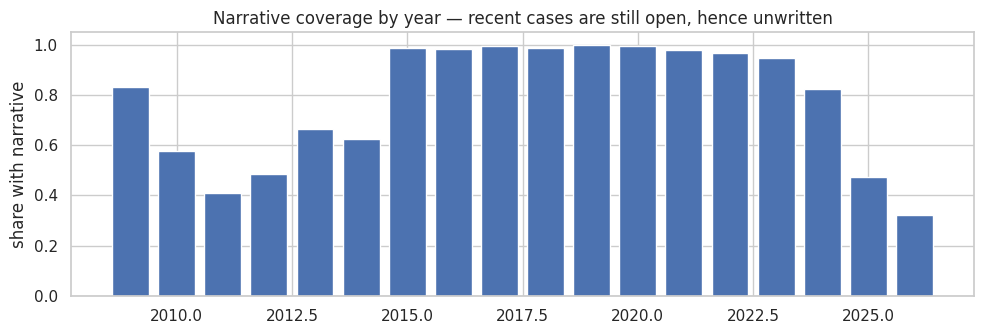

In [2]:
cov = df.groupby("Year")["has_narrative"].mean()
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(cov.index, cov.values, color="#4C72B0")
ax.set_title("Narrative coverage by year — recent cases are still open, hence unwritten")
ax.set_ylabel("share with narrative"); ax.set_ylim(0, 1.05)
plt.tight_layout(); plt.show()

## 1. Attack-vector rules

Priority order matters: a ransomware narrative usually also matches generic hacking language,
so more specific rules are listed first and win the `Primary Vector` assignment.

In [3]:
VECTOR_RULES = {  # order = priority for primary assignment (most specific first)
    "Ransomware":
        r"ransomware|\bransom\b",
    "Phishing / email compromise":
        r"phishing|phished|email account[s]?\b.{0,60}(?:compromis|access|hack)|compromised.{0,30}email",
    "Other hacking / IT intrusion":
        r"\bhack|malware|virus\b|cyber|intrusion|breach of (?:its|the|their).{0,30}(?:network|system|server)"
        r"|network server.{0,40}(?:compromis|breach|access)"
        r"|unauthorized (?:access|party).{0,40}(?:network|server|system)|it system|security incident",
    "Insider snooping / misuse":
        r"(?:employee|workforce member|staff member|nurse|physician)s?\b"
        r".{0,90}(?:impermissibl|improperly|without authorization|unauthorized|snoop|inappropriately)",
    "Stolen device / burglary":
        r"(?:stolen|theft|burglar|broke into|break-in).{0,80}"
        r"(?:laptop|desktop|computer|thumb drive|flash drive|hard drive|phone|tablet|device|server|binder|paper|record|film|car|vehicle|office)"
        r"|(?:laptop|device|computer)s?\b.{0,40}(?:was|were) stolen",
    "Lost device / records":
        r"\blost\b|misplaced|could not be located|missing",
    "Improper disposal":
        r"disposal|disposed|dumpster|recycl|shredd",
    "Misdirected / inadvertent disclosure":
        r"mailing error|mailing vendor|misdirect|wrong (?:recipient|address|patient|fax)"
        r"|\bfax(?:ed)?\b.{0,40}(?:wrong|incorrect|error)|envelope|mailed.{0,60}(?:error|incorrect|wrong|other)"
        r"|mistakenly (?:posted|sent|emailed|mailed|disclosed|attached)"
        r"|inadvertently (?:posted|disclosed|sent|emailed|exposed|made|attached)"
        r"|(?:posted|accessible|viewable).{0,40}(?:website|internet|publicly|online)|human error",
}

REMEDIATION_RULES = {
    "New/updated safeguards":   r"safeguard",
    "Staff retrained":          r"retrain|additional training|workforce training|re-educat",
    "Credit monitoring offered": r"credit monitoring|identity (?:theft )?protection",
    "Corrective action plan":   r"corrective action",
    "OCR technical assistance": r"technical assistance",
    "Discipline / termination": r"sanction|disciplin|terminat|dismissed",
    "Encryption implemented":   r"implement.{0,50}encrypt|encrypt(?:ed|ion).{0,30}(?:devices|laptops|all)",
    "Policies revised":         r"polic(?:y|ies).{0,50}(?:revis|updat|implement|develop|strengthen)",
}

for name, pattern in VECTOR_RULES.items():
    df[f"vec: {name}"] = wd.str.contains(pattern, regex=True)
for name, pattern in REMEDIATION_RULES.items():
    df[f"rem: {name}"] = wd.str.contains(pattern, regex=True)

primary = pd.Series("Other / unspecified", index=df.index)
for name in reversed(list(VECTOR_RULES)):          # apply lowest priority first,
    primary[df[f"vec: {name}"]] = name             # highest priority overwrites last
primary[~df["has_narrative"]] = "No narrative"
df["Primary Vector"] = primary

df["Primary Vector"].value_counts()

Primary Vector
No narrative                            1416
Other hacking / IT intrusion            1330
Ransomware                              1225
Phishing / email compromise             1143
Other / unspecified                     1095
Misdirected / inadvertent disclosure     629
Stolen device / burglary                 435
Insider snooping / misuse                283
Lost device / records                    166
Improper disposal                         73
Name: count, dtype: int64

## 2. Rule validation — read actual narratives per vector

In [4]:
pd.set_option("display.max_colwidth", 200)
for name in VECTOR_RULES:
    hits = df[df["Primary Vector"] == name]
    print(f"--- {name} ({len(hits):,}) " + "-" * 40)
    for t in hits["Web Description"].sample(min(2, len(hits)), random_state=7):
        print("  *", t[:190].replace(chr(10), " "))
    print()

--- Ransomware (1,225) ----------------------------------------
  * The covered entities (CE), Maternal Fetal Medicine Associates, PLLC, Carnegie Hill Imaging for Women, and Carnegie Women’s Health, reported that it experienced a ransomware attack that discl
  * The covered entity (CE), Preferred Hospital Leasing Van Horn dba Culberson Hospital, reported that its business associate was the victim of a ransomware attack that compromised the protected

--- Phishing / email compromise (1,143) ----------------------------------------
  * The covered entity (CE), CareOregon, Inc., reported that an employee was the target of an email phishing scheme that affected the protected health information (PHI) of 1,786 individuals. The
  * Benefit Recovery Specialists, a business associate (BA), reported that it was the victim of a cybersecurity attack that affected the protected health information (PHI) of 447,354 patients. T

--- Other hacking / IT intrusion (1,330) --------------------------------

## 3. What the vectors show

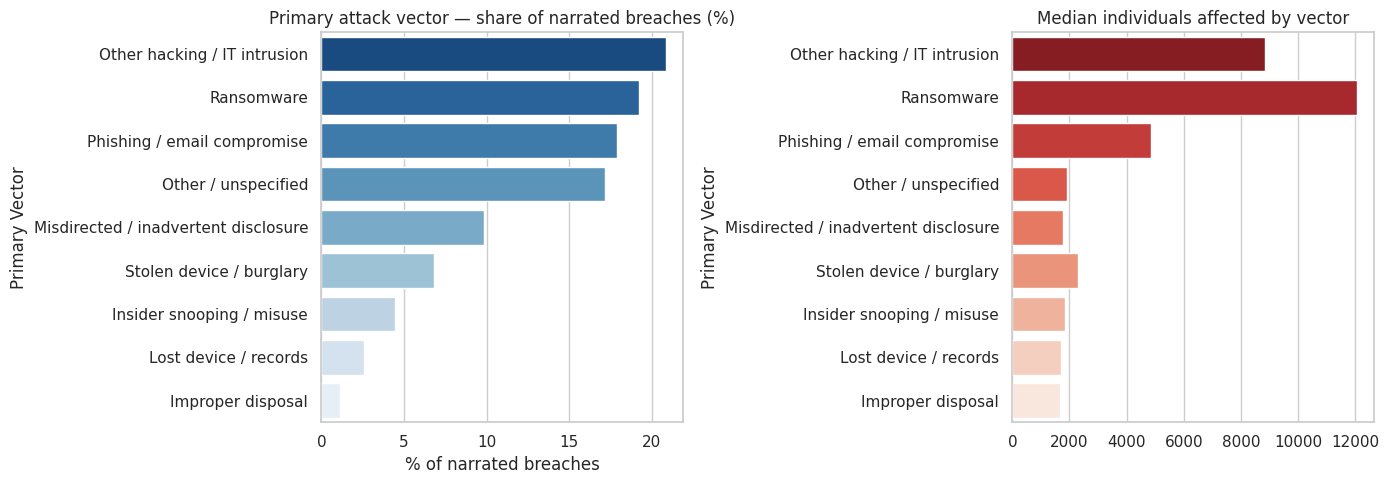

In [5]:
n = df[df["has_narrative"]]
share = n["Primary Vector"].value_counts(normalize=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=share.values * 100, y=share.index, hue=share.index,
            ax=axes[0], palette="Blues_r", legend=False)
axes[0].set_title("Primary attack vector — share of narrated breaches (%)")
axes[0].set_xlabel("% of narrated breaches")

sev = n.groupby("Primary Vector")["Individuals Affected"].median().reindex(share.index)
sns.barplot(x=sev.values, y=sev.index, hue=sev.index, ax=axes[1], palette="Reds_r", legend=False)
axes[1].set_title("Median individuals affected by vector")
plt.tight_layout(); plt.show()

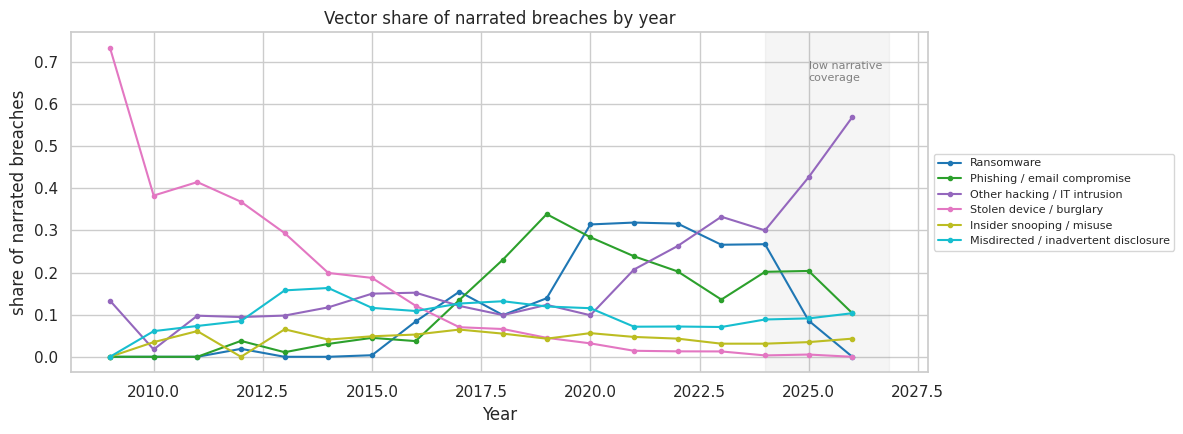

Ransomware breaches by year: pre-2016 total = 3,  peak = 223 (2021)


In [6]:
order = ["Ransomware", "Phishing / email compromise", "Other hacking / IT intrusion",
         "Stolen device / burglary", "Insider snooping / misuse",
         "Misdirected / inadvertent disclosure"]
trend = (n[n["Primary Vector"].isin(order)]
         .groupby(["Year", "Primary Vector"]).size().unstack(fill_value=0))
yr_tot = n.groupby("Year").size()
trend_share = trend.div(yr_tot, axis=0)

fig, ax = plt.subplots(figsize=(12, 4.5))
trend_share[order].plot(ax=ax, marker="o", ms=3, colormap="tab10")
ax.set_title("Vector share of narrated breaches by year")
ax.set_ylabel("share of narrated breaches")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=8)
ax.axvspan(2024, ax.get_xlim()[1], alpha=0.08, color="gray")
ax.annotate("low narrative\ncoverage", xy=(2025, ax.get_ylim()[1]*0.85), fontsize=8, color="gray")
plt.tight_layout(); plt.show()

r = trend["Ransomware"]
print(f"Ransomware breaches by year: pre-2016 total = {r.loc[:2015].sum()},  "
      f"peak = {r.max()} ({r.idxmax()})")

**Ransomware is a post-2016 phenomenon** — essentially absent before 2016 (3 cases total),
then ~200+ narrated breaches per year through 2020–2023. **It is also the most damaging vector**:
median 12,060 individuals per breach vs 4,845 for phishing and under 2,400 for every
physical/human-error vector. Phishing/email compromise rose in parallel. The apparent post-2023
decline is partly a coverage artifact (those cases are still open, shaded region).

## 4. What entities do after a breach

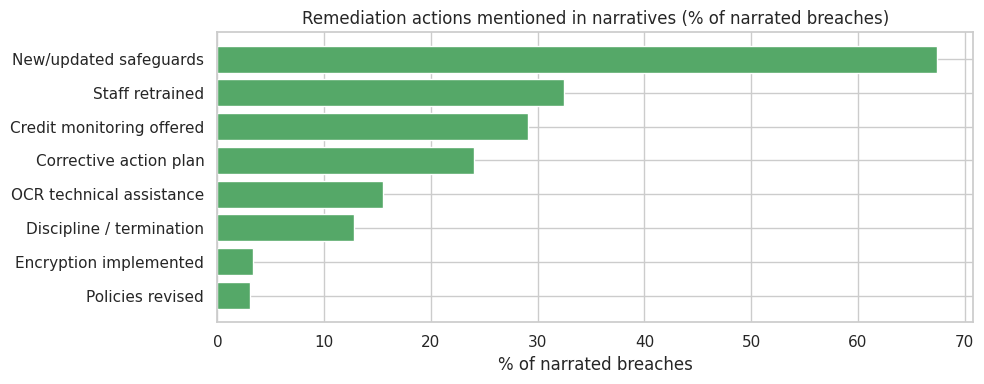

Credit monitoring offered: 36% of ransomware/phishing breaches vs 20% of misdirected-disclosure breaches


In [7]:
rem_cols = [c for c in df.columns if c.startswith("rem: ")]
rem = n[rem_cols].mean().sort_values() * 100
rem.index = [c[5:] for c in rem.index]

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(rem.index, rem.values, color="#55A868")
ax.set_title("Remediation actions mentioned in narratives (% of narrated breaches)")
ax.set_xlabel("% of narrated breaches")
plt.tight_layout(); plt.show()

cm = (n[n["vec: Ransomware"] | n["vec: Phishing / email compromise"]]["rem: Credit monitoring offered"].mean(),
      n[n["Primary Vector"] == "Misdirected / inadvertent disclosure"]["rem: Credit monitoring offered"].mean())
print(f"Credit monitoring offered: {cm[0]:.0%} of ransomware/phishing breaches vs {cm[1]:.0%} of misdirected-disclosure breaches")

## 5. Save extracted features

In [8]:
out_cols = (["Name of Covered Entity", "State", "Covered Entity Type", "Individuals Affected",
             "Year", "Primary Breach Type", "Business Associate Present", "has_narrative",
             "Primary Vector"]
            + [c for c in df.columns if c.startswith("vec: ") or c.startswith("rem: ")])
df[out_cols].to_csv("../data/breach_vectors.csv", index=False)
print(f"saved ../data/breach_vectors.csv ({len(df):,} rows, {len(out_cols)} cols)")

saved ../data/breach_vectors.csv (7,795 rows, 25 cols)


## Findings

1. **Hacking-family vectors dominate narrated breaches**: ransomware (~19%), phishing/email
   compromise (~18%), other network intrusion (~21%) — together over half of all narrated cases.
2. **Ransomware is both recent and severe**: near-zero before 2016, then the single most damaging
   vector (median 12k individuals per breach — 5–7× the physical/human-error vectors).
3. **Human-error vectors persist at small scale**: misdirected mail/faxes/postings (~10%),
   insider snooping (~4%), lost records (~3%) — high frequency in older years, low severity.
4. **Remediation is boilerplate-heavy**: "additional safeguards" appears in ~67% of narratives;
   staff retraining ~32%; credit monitoring ~29%; discipline/termination ~12%; encryption
   specifically ~3% — rarely named even where device theft was the cause.
5. ~17% of narratives state no clear mechanism, and 18% of breaches (mostly 2024–26, plus
   database-null placeholders) have no usable narrative — all shares above are of narrated breaches only.

**Limits:** regex extraction (no trained classifier); OCR narrative style changed over the years;
multi-vector incidents get one primary label by rule priority.